In [1]:
# Import libraries for NLP Sentiment Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import re
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Create sample customer reviews dataset
# In real world this comes from Google Reviews, Twitter, App Store etc.
print("=" * 50)
print("CREATING CUSTOMER REVIEWS DATASET")
print("=" * 50)

reviews_data = {
    'customerID': [
        'C001', 'C002', 'C003', 'C004', 'C005',
        'C006', 'C007', 'C008', 'C009', 'C010',
        'C011', 'C012', 'C013', 'C014', 'C015',
        'C016', 'C017', 'C018', 'C019', 'C020'
    ],
    'review': [
        "The service is absolutely terrible, I am cancelling my plan",
        "Very happy with the network coverage, excellent service!",
        "Worst customer support ever, they never solve my issues",
        "Great value for money, highly recommend this plan",
        "My internet keeps disconnecting every day, very frustrated",
        "Amazing speed and reliable connection, love it!",
        "Bills are too high and service quality is poor",
        "Super fast internet and great customer care team",
        "I have been waiting for support for 3 weeks, no response",
        "Smooth experience overall, no complaints at all",
        "They charged me extra without any notice, very angry",
        "Excellent coverage even in rural areas, impressed",
        "Connection drops frequently, thinking of switching",
        "Best telecom provider I have used in years",
        "Very disappointed with the slow speed and high cost",
        "Outstanding service and quick issue resolution",
        "Pathetic network in my area, always getting poor signal",
        "Affordable plans and good customer service",
        "Fed up with constant billing errors every month",
        "Totally satisfied with the service, renewing my plan"
    ],
    'churn': [
        1, 0, 1, 0, 1,
        0, 1, 0, 1, 0,
        1, 0, 1, 0, 1,
        0, 1, 0, 1, 0
    ]
}

df_reviews = pd.DataFrame(reviews_data)

print(f"✅ Reviews dataset created!")
print(f"Total Reviews : {len(df_reviews)}")
print(f"Churned       : {df_reviews['churn'].sum()}")
print(f"Stayed        : {len(df_reviews) - df_reviews['churn'].sum()}")
print("\nSample reviews:")
df_reviews.head() 

CREATING CUSTOMER REVIEWS DATASET
✅ Reviews dataset created!
Total Reviews : 20
Churned       : 10
Stayed        : 10

Sample reviews:


,customerID,review,churn
0,C001,"The service is absolutely terrible, I am cance...",1
1,C002,"Very happy with the network coverage, excellen...",0
2,C003,"Worst customer support ever, they never solve ...",1
3,C004,"Great value for money, highly recommend this plan",0
4,C005,"My internet keeps disconnecting every day, ver...",1


In [3]:
# Clean the review text
print("=" * 50)
print("CLEANING REVIEWS")
print("=" * 50)

def clean_text(text):
    # Step 1: Convert to lowercase
    text = text.lower()
    
    # Step 2: Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Step 3: Remove extra spaces
    text = text.strip()
    
    return text

# Apply cleaning to all reviews
df_reviews['clean_review'] = df_reviews['review'].apply(clean_text)

print("✅ Reviews cleaned successfully!")
print("\nBefore and After Cleaning:")
print("-" * 50)
for i in range(3):
    print(f"Original : {df_reviews['review'][i]}")
    print(f"Cleaned  : {df_reviews['clean_review'][i]}")
    print("-" * 50)

CLEANING REVIEWS
✅ Reviews cleaned successfully!

Before and After Cleaning:
--------------------------------------------------
Original : The service is absolutely terrible, I am cancelling my plan
Cleaned  : the service is absolutely terrible i am cancelling my plan
--------------------------------------------------
Original : Very happy with the network coverage, excellent service!
Cleaned  : very happy with the network coverage excellent service
--------------------------------------------------
Original : Worst customer support ever, they never solve my issues
Cleaned  : worst customer support ever they never solve my issues
--------------------------------------------------


In [4]:
# Perform Sentiment Analysis using TextBlob
print("=" * 50)
print("SENTIMENT ANALYSIS")
print("=" * 50)

def get_sentiment(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity

    # Classify based on polarity score
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

def get_polarity(text):
    return TextBlob(text).sentiment.polarity

def get_subjectivity(text):
    return TextBlob(text).sentiment.subjectivity

# Apply to all reviews
df_reviews['sentiment']    = df_reviews['clean_review'].apply(get_sentiment)
df_reviews['polarity']     = df_reviews['clean_review'].apply(get_polarity)
df_reviews['subjectivity'] = df_reviews['clean_review'].apply(get_subjectivity)

# Show results
print("✅ Sentiment analysis complete!")
print("\nSentiment Distribution:")
print(df_reviews['sentiment'].value_counts())
print("\nSample Results:")
df_reviews[['review', 'sentiment', 'polarity']].head(10)

SENTIMENT ANALYSIS
✅ Sentiment analysis complete!

Sentiment Distribution:
sentiment
Positive    10
Negative     7
Neutral      3
Name: count, dtype: int64

Sample Results:


,review,sentiment,polarity
0,"The service is absolutely terrible, I am cance...",Negative,-1.000000
1,"Very happy with the network coverage, excellen...",Positive,1.000000
2,"Worst customer support ever, they never solve ...",Negative,-1.000000
3,"Great value for money, highly recommend this plan",Positive,0.480000
4,"My internet keeps disconnecting every day, ver...",Negative,-0.910000
5,"Amazing speed and reliable connection, love it!",Positive,0.550000
6,Bills are too high and service quality is poor,Negative,-0.120000
7,Super fast internet and great customer care team,Positive,0.444444
8,"I have been waiting for support for 3 weeks, n...",Neutral,0.000000
9,"Smooth experience overall, no complaints at all",Positive,0.200000


SENTIMENT VISUALIZATION


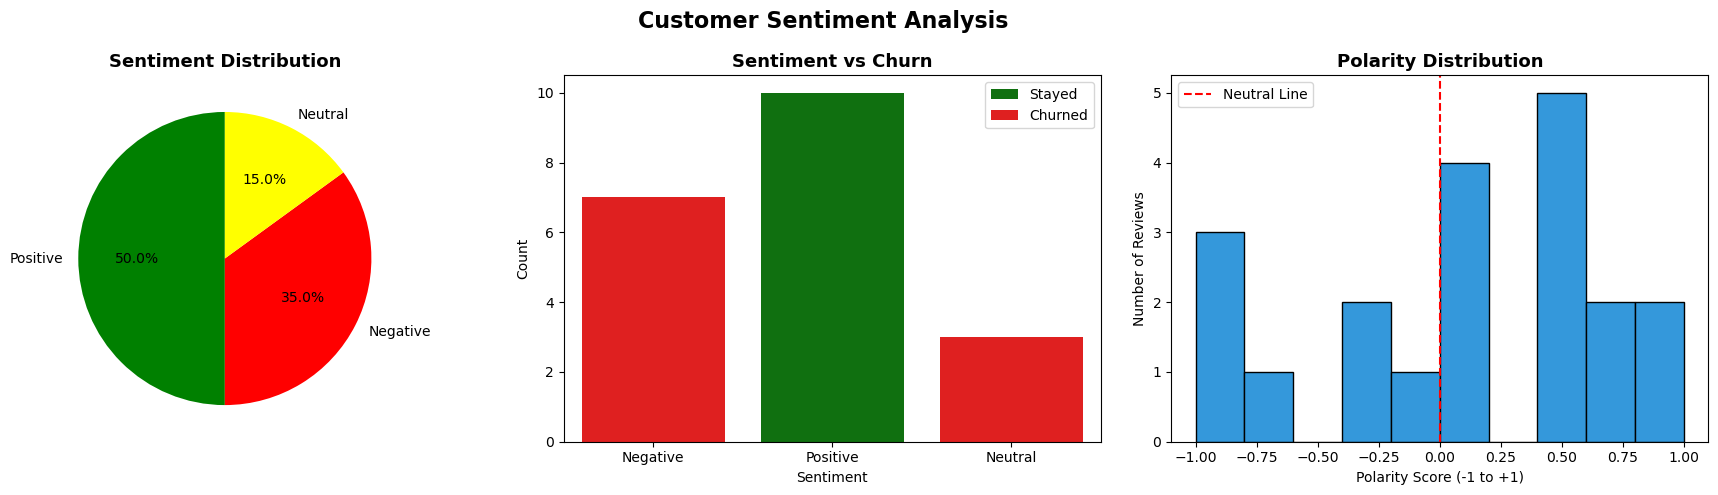


✅ Sentiment visualization complete!


In [11]:
# Visualize Sentiment Analysis Results
print("=" * 50)
print("SENTIMENT VISUALIZATION")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Sentiment Distribution
colors = ['green', 'red', 'yellow']
sentiment_counts = df_reviews['sentiment'].value_counts()
axes[0].pie(sentiment_counts,
            labels=sentiment_counts.index,
            colors=colors,
            autopct='%1.1f%%',
            startangle=90)
axes[0].set_title("Sentiment Distribution",
                  fontsize=13, fontweight='bold')

# 2. Sentiment vs Churn
sns.countplot(x='sentiment', hue='churn',
              data=df_reviews,
              palette=['green', 'red'],
              ax=axes[1])
axes[1].set_title("Sentiment vs Churn",
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Count")
axes[1].legend(['Stayed', 'Churned'])

# 3. Polarity Distribution
axes[2].hist(df_reviews['polarity'],
             bins=10,
             color='#3498db',
             edgecolor='black')
axes[2].set_title("Polarity Distribution",
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel("Polarity Score (-1 to +1)")
axes[2].set_ylabel("Number of Reviews")
axes[2].axvline(x=0, color='red',
                linestyle='--',
                label='Neutral Line')
axes[2].legend()

plt.suptitle("Customer Sentiment Analysis",
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Sentiment visualization complete!")

In [12]:
# Save sentiment results
print("=" * 50)
print("SAVING SENTIMENT RESULTS")
print("=" * 50)

# Save to data folder
df_reviews.to_csv('../data/customer_sentiment.csv', index=False)

# Print summary
print("✅ Sentiment data saved as 'customer_sentiment.csv'")
print("\n📊 Final Summary:")
print("-" * 50)

for sentiment in ['Positive', 'Negative', 'Neutral']:
    count = len(df_reviews[df_reviews['sentiment'] == sentiment])
    churned = len(df_reviews[(df_reviews['sentiment'] == sentiment) &
                             (df_reviews['churn'] == 1)])
    print(f"{sentiment:10} → Total: {count} | Churned: {churned}")

print("-" * 50)
print(f"\nKey Insight:")
negative = df_reviews[df_reviews['sentiment'] == 'Negative']
churn_rate = (negative['churn'].sum() / len(negative)) * 100
print(f"Churn rate among NEGATIVE sentiment customers: {churn_rate:.1f}%")

print("\n✅ Week 3 NLP Complete!")

SAVING SENTIMENT RESULTS
✅ Sentiment data saved as 'customer_sentiment.csv'

📊 Final Summary:
--------------------------------------------------
Positive   → Total: 10 | Churned: 0
Negative   → Total: 7 | Churned: 7
Neutral    → Total: 3 | Churned: 3
--------------------------------------------------

Key Insight:
Churn rate among NEGATIVE sentiment customers: 100.0%

✅ Week 3 NLP Complete!
